In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [2]:
model = load_model("../../saved_models/emotion_model.keras")

In [3]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    "../../dataset/test",
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [5]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step


In [7]:
emotion_labels = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise'
]

In [16]:
report = classification_report(
    y_true,
    y_pred,
    target_names=emotion_labels
)

print(report)

              precision    recall  f1-score   support

       angry       0.44      0.45      0.44       958
     disgust       0.89      0.29      0.44       111
        fear       0.44      0.29      0.35      1024
       happy       0.70      0.79      0.74      1774
     neutral       0.47      0.53      0.50      1233
         sad       0.40      0.44      0.42      1247
    surprise       0.76      0.68      0.72       831

    accuracy                           0.55      7178
   macro avg       0.59      0.49      0.51      7178
weighted avg       0.55      0.55      0.54      7178



In [17]:
with open("../../reports/classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
from sklearn.metrics import confusion_matrix

In [10]:
cm = confusion_matrix(y_true, y_pred)

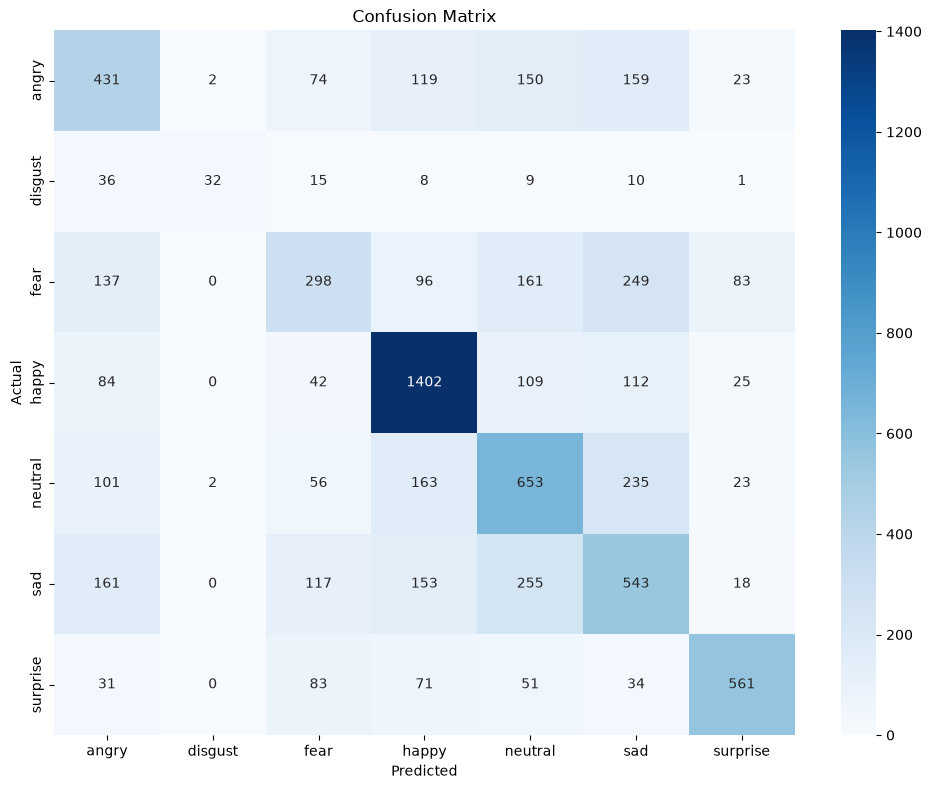

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.savefig("../../reports/confusion_matrix.png")

plt.show()

In [12]:
plt.savefig('confusion_matrix.png')

<Figure size 640x480 with 0 Axes>